In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [4]:
file_name=f'sales_data.csv'
if not os.path.exists(file_name):
    print(f'File: {file_name} Not Found')
    exit()
else:
    print(f'File: {file_name} Found')

File: sales_data.csv Found


In [5]:
df=pd.read_csv(file_name)
print("file loaded !")

file loaded !


In [7]:
print(f'the shape of the dataset is (row,columns):{df.shape} \n')

the shape of the dataset is (row,columns):(50, 5) 



In [8]:
print(f'\n first 5 rows are: \n{df.head()}')


 first 5 rows are: 
   Customer_ID   Age         City  Spending  Visits_Per_Month
0            1  25.0     New York     500.0                 2
1            2  30.0  Los Angeles     700.0                 4
2            3   NaN      Chicago     450.0                 3
3            4  45.0      Chicago    1500.0                10
4            5  30.0     New York       NaN                 5


In [9]:
print(f'\n last 5 rows are: \n{df.tail()}')


 last 5 rows are: 
    Customer_ID   Age         City  Spending  Visits_Per_Month
45           46  29.0     New York     620.0                 3
46           47  53.0  Los Angeles    1700.0                10
47           48   NaN      Houston     810.0                 4
48           49  27.0        Miami     530.0                 2
49           50  32.0      Chicago     740.0                 5


In [10]:
print(df.describe())

       Customer_ID         Age     Spending  Visits_Per_Month
count     50.00000   45.000000    46.000000         50.000000
mean      25.50000   38.888889  1070.652174          4.800000
std       14.57738   19.292276  1025.246642          2.539484
min        1.00000   22.000000   300.000000          1.000000
25%       13.25000   29.000000   585.000000          3.000000
50%       25.50000   33.000000   815.000000          4.500000
75%       37.75000   44.000000  1187.500000          6.000000
max       50.00000  120.000000  6000.000000         10.000000


In [11]:

print(f"missing values\n{df.isnull().sum()}\n")

missing values
Customer_ID         0
Age                 5
City                0
Spending            4
Visits_Per_Month    0
dtype: int64



In [12]:

median_age=df['Age'].median()
print(f'meadian of age : {median_age}')

meadian of age : 33.0


In [13]:

df['Age']=df['Age'].fillna(median_age)

In [14]:
df['Spending']=df['Spending'].fillna(df["Spending"].mean())
print(df.head)

<bound method NDFrame.head of     Customer_ID    Age         City     Spending  Visits_Per_Month
0             1   25.0     New York   500.000000                 2
1             2   30.0  Los Angeles   700.000000                 4
2             3   33.0      Chicago   450.000000                 3
3             4   45.0      Chicago  1500.000000                10
4             5   30.0     New York  1070.652174                 5
5             6   22.0  Los Angeles   600.000000                 2
6             7  120.0     New York  5000.000000                 1
7             8   35.0      Houston   800.000000                 4
8             9   28.0        Miami   300.000000                 1
9            10   50.0      Chicago  1200.000000                 8
10           11   41.0     New York   900.000000                 5
11           12   33.0  Los Angeles   450.000000                 3
12           13   29.0      Houston   550.000000                 2
13           14   33.0        Mi

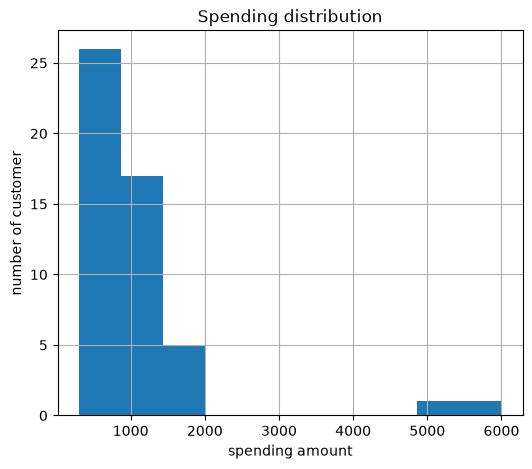

In [17]:
plt.figure(figsize=(6,5))
plt.title("Spending distribution")
df['Spending'].hist(bins=10)
plt.xlabel('spending amount')
plt.ylabel('number of customer')
plt.show()

                  Customer_ID       Age  Spending  Visits_Per_Month
Customer_ID          1.000000 -0.066118 -0.042168          0.148848
Age                 -0.066118  1.000000  0.962251          0.117690
Spending            -0.042168  0.962251  1.000000          0.029483
Visits_Per_Month     0.148848  0.117690  0.029483          1.000000


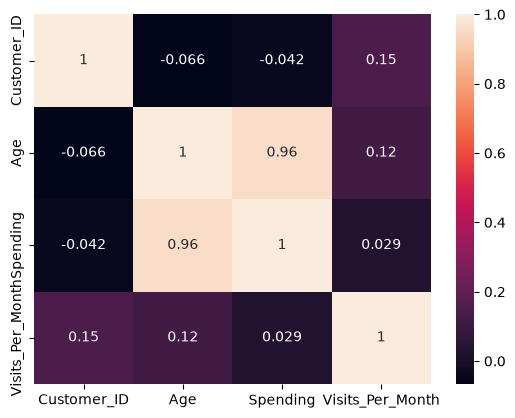

In [19]:
corr=df.corr(numeric_only=True)
print(corr)
sns.heatmap(corr,annot=True)
plt.show()

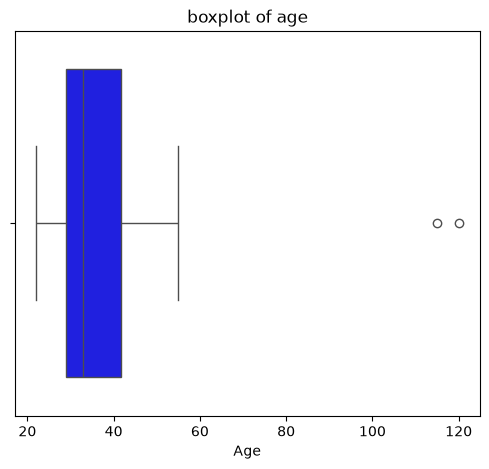

In [20]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Age'],color='blue')
plt.title('boxplot of age')
plt.show()

In [26]:
print(df[df['Age']>100])

    Customer_ID    Age      City  Spending  Visits_Per_Month
6             7  120.0  New York    5000.0                 1
27           28  115.0   Houston    6000.0                 1


In [ ]:
q3=np.quantile(75)
q1=np.nanquantile(25)
iqr=q3-q1
up=iqr+1.5*q3
lb=iqr-1.5*q1
